In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/pet_adoption_data.csv')

In [2]:
df.describe(include='all')

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
count,2007.000000,2007,2007,2007.000000,2007,2007,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
unique,NaN,4,7,NaN,5,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Dog,Rabbit,NaN,White,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,522,493,NaN,420,714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1503.000000,NaN,NaN,92.279522,NaN,NaN,15.705776,0.701046,0.196313,43.974091,249.142003,0.301943,0.328351
std,579.515315,NaN,NaN,52.148363,NaN,NaN,8.327749,0.457914,0.397307,25.740253,142.887040,0.459215,0.469730
min,500.000000,NaN,NaN,1.000000,NaN,NaN,1.018198,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1001.500000,NaN,NaN,48.000000,NaN,NaN,8.730396,0.000000,0.000000,21.000000,127.000000,0.000000,0.000000
50%,1503.000000,NaN,NaN,94.000000,NaN,NaN,15.925416,1.000000,0.000000,45.000000,242.000000,0.000000,0.000000
75%,2004.500000,NaN,NaN,138.000000,NaN,NaN,22.737180,1.000000,0.000000,66.000000,375.000000,1.000000,1.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   str    
 2   Breed               2007 non-null   str    
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   str    
 5   Size                2007 non-null   str    
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), str(4)
memory usage: 204.0 KB


zbior danych kompletny nie musimy inputowac

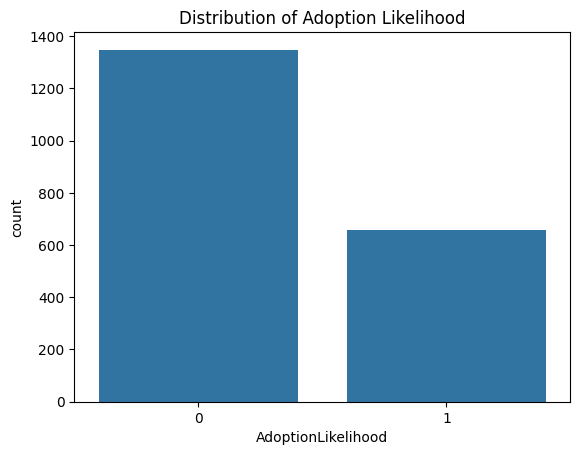

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='AdoptionLikelihood', data=df)
plt.title('Distribution of Adoption Likelihood')
plt.show()

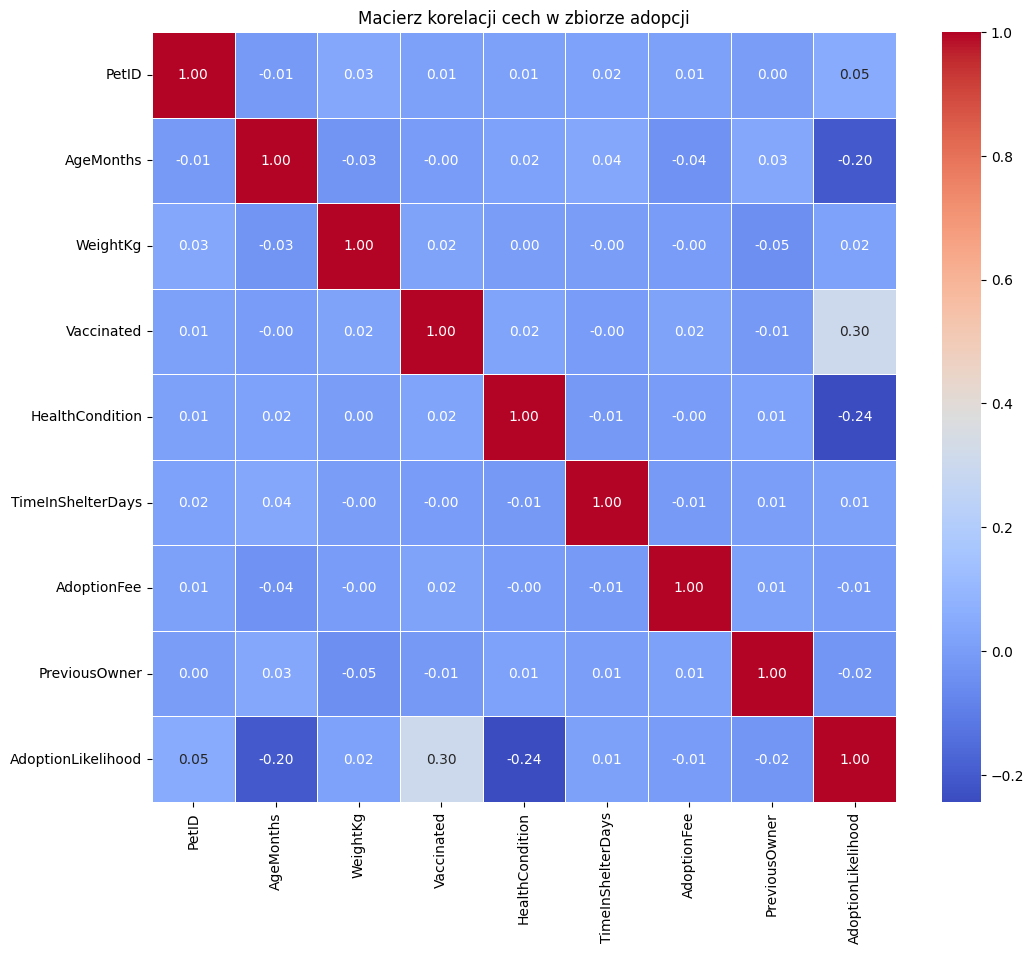

In [ ]:
corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=True,       
            cmap='coolwarm',  
            fmt=".2f",        
            linewidths=0.5)   

plt.title("Macierz korelacji cech w zbiorze adopcji")
plt.show()

In [ ]:
# Usunięcie niepotrzebnej kolumny PetID
df = df.drop(columns=['PetID'])

# Funkcja symulacji budżetu
def symulacja_budzetu(y_true, y_proba, budzet=200, koszt_reklamy=10):
    """
    Funkcja oceniająca kampanię na podstawie przewidzianych prawdopodobieństw.
    
    Parametry:
    y_true - rzeczywiste etykiety (1 = szansa na adopcję)
    y_proba - prawdopodobieństwa klasy 1 wyznaczone przez model
    budzet - całkowity budżet (zgodnie z zadaniem 200$)
    koszt_reklamy - koszt jednej reklamy (10$)
    
    Zwraca:
    Oczekiwaną, łączną liczbę zaadoptowanych zwierząt.
    """
    # Maksymalna liczba zwierząt, które możemy zareklamować
    max_reklam = budzet // koszt_reklamy 
    
    # Tworzymy pomocniczy DataFrame
    wyniki = pd.DataFrame({'y_true': y_true, 'proba': y_proba})
    # Sortujemy malejąco po prawdopodobieństwie adopcji wg. modelu
    wyniki_posortowane = wyniki.sort_values(by='proba', ascending=False)
    
    # Bierzemy tyle zwierząt, na ile pozwala budżet
    wybrane = wyniki_posortowane.head(max_reklam)
    
    # Wyliczamy wartość oczekiwaną adopcji
    # TP (prawdziwie pozytywni) dają 70% skuteczności
    # FP (fałszywie pozytywni) dają 10% skuteczności
    tp = (wybrane['y_true'] == 1).sum()
    fp = (wybrane['y_true'] == 0).sum()
    
    oczekiwana_liczba_adopcji = (tp * 0.70) + (fp * 0.10)
    
    return oczekiwana_liczba_adopcji

In [ ]:
y = df['AdoptionLikelihood']
X = df.drop('AdoptionLikelihood', axis=1)

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)